# Исследовательский анализ данных сервиса «Яндекс Афиша»

### Автор проекта
Егоров Д.Д.

### Описание проекта
В данном проекте проводится исследование пользовательской активности и финансовых показателей сервиса «Яндекс Афиша». На основе данных за 2024 год необходимо выяснить причины аномального поведения метрик в осенний период: значительного роста количества заказов при одновременном снижении среднего чека.

### Цель исследования
Выявить факторы, повлиявшие на изменение ключевых показателей сервиса осенью 2024 года, и проверить статистические гипотезы относительно активности пользователей различных типов устройств.

### Описание данных

**Таблица `orders` (заказы):**
* `order_id` — уникальный идентификатор заказа;
* `user_id` — уникальный идентификатор пользователя;
* `created_dt_msk` — дата заказа (МСК);
* `created_ts_msk` — дата и время заказа (МСК);
* `event_id` — идентификатор мероприятия;
* `cinema_circuit` — название киносети (при наличии);
* `age_limit` — возрастной рейтинг мероприятия;
* `currency_code` — валюта (rub или kzt);
* `device_type_canonical` — тип устройства (mobile или desktop);
* `revenue` — выручка с заказа в валюте заказа;
* `service_name` — название билетного партнёра;
* `tickets_count` — количество билетов в заказе;
* `total` — общая сумма заказа;
* `days_since_prev` — количество дней с момента предыдущего заказа.

**Таблица `events` (мероприятия):**
* `event_id` — уникальный идентификатор мероприятия;
* `event_name` — название мероприятия;
* `event_type_description` — подробный тип мероприятия;
* `event_type_main` — основной тип мероприятия (театр, спорт и т.д.);
* `region_name` / `city_name` — регион и город проведения;
* `venue_name` / `venue_address` — название и адрес площадки.

**Таблица `currency` (курсы валют):**
* `data` — дата;
* `curs` — курс тенге к рублю (за 100 единиц);
* `nominal` — номинал (100).

### Структура проекта
1. **Предобработка данных**: Объединение таблиц, очистка от аномалий и дубликатов, нормализация типов данных.
2. **Исследовательский анализ данных**: Сравнение летнего и осеннего сезонов, анализ структуры спроса и цен.
3. **Анализ активности**: Изучение ежедневной активности пользователей, частоты покупок и недельной цикличности.
4. **Статистический анализ**: Проверка гипотез о различиях в поведении мобильных и десктопных пользователей.
5. **Общий вывод**: Итоговые выводы и бизнес-рекомендации.

## Шаг 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем все необходимые библиотеки
try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import phik
    import missingno as msno
    from scipy import stats as st
except ImportError:
    !pip install pandas numpy matplotlib seaborn phik missingno scipy
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import phik
    import missingno as msno
    from scipy import stats as st

In [2]:
# Загрузка данных
orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
currency = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [3]:
# Выводим общую информацию и первые 10 строк датафрейма orders на экран
display(orders.info())
display(orders.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

None

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,Облачко,3,8206.70,19.0
6,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,201953,нет,16,rub,desktop,917.83,Край билетов,4,9178.26,NaN
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,Лучшие билеты,1,955.52,NaN
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,Лучшие билеты,2,2494.73,16.0
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,Лови билет!,4,17773.87,NaN


In [4]:
# Выводим общую информацию и первые 10 строк датафрейма events на экран
display(events.info())
display(events.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


None

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"
5,8858,08008ffd-331c-4d77-8aad-c91691f87388,спектакль,театр,№896,Каменевский регион,Глиногорск,213,2148,"Лекции по искусству ""Хоровод"" и партнеры","пер. 50 лет Победы, д. 21 к. 90"
6,8863,2dc56536-e5ae-4d3a-9f00-f39c0ebe5b65,спектакль,театр,№3977,Медовская область,Радужсвет,47,2897,"Фестиваль уличного искусства ""Начало"" Инкорпор...","алл. Урицкого, д. 4/5 к. 1/3"
7,9041,1ab79186-41a8-420e-b618-dea51afd2c6f,спектакль,театр,№3582,Светополянский округ,Глиноград,54,3922,"Творческое агентство ""Симфония"" Лтд","бул. К.Маркса, д. 8/6"
8,9942,474ca8f8-3525-4ac0-9a98-4c1045e2fa6d,спектакль,театр,№1797,Широковская область,Радужнополье,35,3975,"Кабинет Искусств ""История"" и партнеры","пр. Гайдара, д. 4 к. 7/1"
9,9992,e36939d8-ef42-4f64-bd72-5a4199dd98f5,спектакль,театр,№1774,Тепляковская область,Горнодолинск,43,3959,"Эстетика ""Rhythm"" Инкорпорэйтед","ш. Вахитова, д. 7/8"


In [5]:
# Выводим общую информацию и первые 10 строк датафрейма currency на экран
display(currency.info())
display(currency.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


None

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [6]:
# Приводим даты к формату datetime (это критично для валют)
orders['created_dt_msk'] = pd.to_datetime(orders['created_dt_msk'])
currency['data'] = pd.to_datetime(currency['data'])

# Объединяем датфреймы orders и events
df = orders.merge(events, on='event_id', how='left')

# Присоединяем датафрейм currency
df = df.merge(currency, left_on='created_dt_msk', right_on='data', how='left')

# Удаляем лишний технический столбец даты
df = df.drop(columns=['data'])

# Проверяем, что количество строк в итоге совпадает с исходным количеством заказов
print(f"Строк в исходных заказах: {len(orders)}")
print(f"Строк в итоговом датафрейме: {len(df)}")

Строк в исходных заказах: 290849
Строк в итоговом датафрейме: 290849


In [7]:
# Выводим общую информацию и первые 10 строк финального датафрейма df на экран
display(df.info())
display(df.head(10))

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                290849 non-null  int64         
 1   user_id                 290849 non-null  object        
 2   created_dt_msk          290849 non-null  datetime64[ns]
 3   created_ts_msk          290849 non-null  object        
 4   event_id                290849 non-null  int64         
 5   cinema_circuit          290849 non-null  object        
 6   age_limit               290849 non-null  int64         
 7   currency_code           290849 non-null  object        
 8   device_type_canonical   290849 non-null  object        
 9   revenue                 290849 non-null  float64       
 10  service_name            290849 non-null  object        
 11  tickets_count           290849 non-null  int64         
 12  total                   290849

None

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address,nominal,curs,cdx
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6",100,18.6972,kzt
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4",100,18.3419,kzt
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6",100,19.6475,kzt
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8",100,18.5010,kzt
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8",100,19.6648,kzt
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,...,№1020,Лугоградская область,Кристалевск,193.0,930.0,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1",100,20.0531,kzt
6,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,201953,нет,16,rub,desktop,917.83,...,№1825,Каменевский регион,Глиногорск,213.0,4035.0,"Выставка ремесел ""Платформа"" Групп","алл. Горняцкая, д. 573",100,18.7730,kzt
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,...,№1637,Поленовский край,Дальнозолотск,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",100,19.3741,kzt
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,...,№1637,Поленовский край,Дальнозолотск,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7",100,19.7185,kzt
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,...,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669",100,18.0419,kzt


### Выводы по Шагу 1 (Загрузка данных и знакомство с ними)

На начальном этапе работы были загружены и изучены три исходных датасета. Первичный осмотр показал следующее:

1. **Таблица `orders` (290 849 записей)**: 
    * Содержит основную информацию о транзакциях. 
    * Обнаружены пропуски в столбце `days_since_prev` (~7.5%), что является нормой для пользователей, совершающих свой первый заказ. 
    * Столбцы с датами и временем требуют преобразования типов из `object` в `datetime`.
    * Выручка представлена в двух валютах (RUB и KZT), что требует дальнейшей нормализации.

2. **Таблица `events` (22 427 записей)**: 
    * Является справочником мероприятий. 
    * Данные по событиям (названия, типы, локации) заполнены полностью. 
    * Идентификатор `event_id` будет использован в качестве ключа для объединения с таблицей заказов.

3. **Таблица `currency` (357 записей)**: 
    * Содержит ежедневный курс тенге к рублю за весь исследуемый период. 
    * Данные готовы для использования в расчете единого показателя выручки.

**Итог**: Данные в целом качественные, критических ошибок при выгрузке не обнаружено. Однако для проведения анализа требуется объединение таблиц в единую структуру, приведение типов данных и расчет дополнительных признаков (выручка в рублях, сезонность).

## Шаг 2. Предобработка данных и подготовка их к исследованию

In [8]:
# Посчитаем и выведем на экран количество пропущенных значений в каждом столбце а также их долю
missing_values = df.isnull().sum()
print('Кол-во пропущенных значений по столбцам:')
print(missing_values)
print()
print('Доля пропущенных значений по столбцам:')
df.isna().sum() / df.shape[0] * 100

Кол-во пропущенных значений по столбцам:
order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
nominal                       0
curs                          0
cdx                           0
dtype: int64

Доля пропущенных значений по столбцам:


order_id                  0.000000
user_id                   0.000000
created_dt_msk            0.000000
created_ts_msk            0.000000
event_id                  0.000000
cinema_circuit            0.000000
age_limit                 0.000000
currency_code             0.000000
device_type_canonical     0.000000
revenue                   0.000000
service_name              0.000000
tickets_count             0.000000
total                     0.000000
days_since_prev           7.543433
event_name                0.081829
event_type_description    0.081829
event_type_main           0.081829
organizers                0.081829
region_name               0.081829
city_name                 0.081829
city_id                   0.081829
venue_id                  0.081829
venue_name                0.081829
venue_address             0.081829
nominal                   0.000000
curs                      0.000000
cdx                       0.000000
dtype: float64

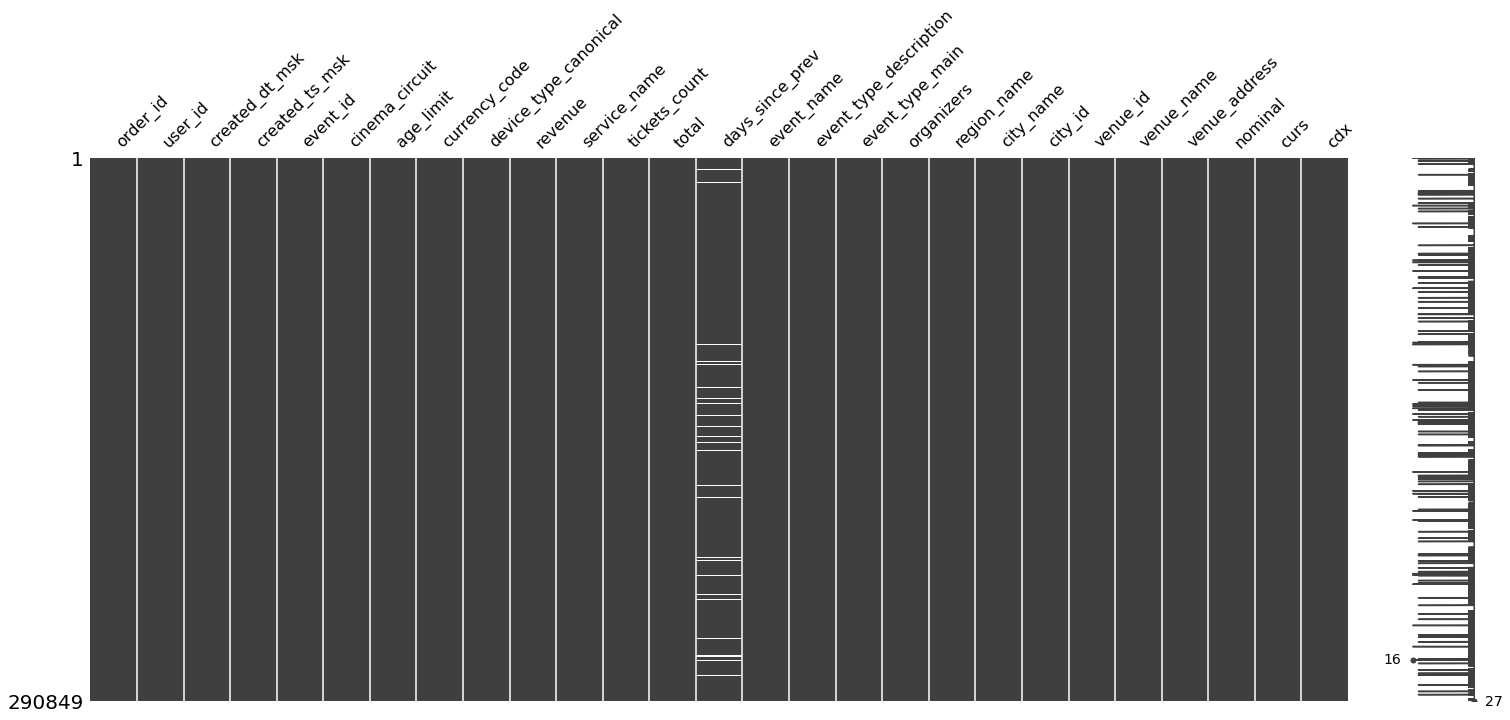

In [9]:
# Выводим матрицу пропущенных значений через библиотеку missingno
msno.matrix(df);

In [10]:
# Переводим время в формат datetime
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])

# Переводим ID в целочисленный тип, поддерживающий пропуски (Int64)
df['city_id'] = df['city_id'].astype('Int64')
df['venue_id'] = df['venue_id'].astype('Int64')

# Самопроверка 1: проверяем обновленные типы данных
print("Обновленные типы данных:")
print(df[['created_ts_msk', 'city_id', 'venue_id']].dtypes)
print("-" * 30)

# Самопроверка 2: смотрим на примеры строк
# Возьмем одну обычную строку и одну из тех 238, где были пропуски
print("Примеры данных (обычная строка и строка с пропусками):")
display(df.loc[[0, df[df['event_name'].isna()].index[0]], 
               ['created_ts_msk', 'city_id', 'venue_id', 'event_name']])

Обновленные типы данных:
created_ts_msk    datetime64[ns]
city_id                    Int64
venue_id                   Int64
dtype: object
------------------------------
Примеры данных (обычная строка и строка с пропусками):


,created_ts_msk,city_id,venue_id,event_name
0,2024-08-20 16:08:03,213,3972,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad
62,2024-10-14 16:27:53,<NA>,<NA>,NaN


In [11]:
# Составим список всех столбцов от мероприятий, где есть пропуски (кроме days_since_prev)
event_columns = [
    'event_name', 'event_type_description', 'event_type_main', 
    'organizers', 'region_name', 'city_name', 'venue_name', 'venue_address'
]

# Заполняем их строкой 'unknown'
df[event_columns] = df[event_columns].fillna('unknown')

# Проверим результат
print("Пропуски после заполнения:")
print(df[event_columns].isna().sum())

Пропуски после заполнения:
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
venue_name                0
venue_address             0
dtype: int64


In [12]:
# Создаём новый столбец revenue_rub через np.where
df['revenue_rub'] = np.where(
    df['currency_code'] == 'kzt',
    (df['revenue'] / df['nominal']) * df['curs'],
    df['revenue']
)

# Округляем до 2 знаков для красоты
df['revenue_rub'] = df['revenue_rub'].round(2)

# Считаем выручку за один билет
df['one_ticket_revenue_rub'] = (df['revenue_rub'] / df['tickets_count']).round(2)

# Проверяем результат
display(df[['currency_code', 'revenue', 'revenue_rub', 'one_ticket_revenue_rub']].head())

,currency_code,revenue,revenue_rub,one_ticket_revenue_rub
0,rub,1521.94,1521.94,380.48
1,rub,289.45,289.45,144.72
2,rub,1258.57,1258.57,314.64
3,rub,8.49,8.49,4.24
4,rub,1390.41,1390.41,463.47


In [13]:
# Выделяем месяц оформления заказа (получим числа от 1 до 12)
df['month'] = df['created_dt_msk'].dt.month

# Создаем столбец с сезонами
conditions = [
    df['month'].isin([12, 1, 2]),   # Зима
    df['month'].isin([3, 4, 5]),    # Весна
    df['month'].isin([6, 7, 8]),    # Лето
    df['month'].isin([9, 10, 11])   # Осень
]

choices = ['зима', 'весна', 'лето', 'осень']

df['season'] = np.select(conditions, choices)

# Проверка: посмотрим, правильно ли распределились сезоны по месяцам
display(df.groupby(['season', 'month']).size())

season  month
лето    6         34683
        7         40925
        8         45044
осень   9         69976
        10       100221
dtype: int64

In [14]:
# Рассчитаем границу 99-го процентиля для выручки и количества билетов
revenue_limit = df['revenue_rub'].quantile(0.99)
tickets_limit = df['tickets_count'].quantile(0.99)

print(f"99% заказов имеют выручку ниже: {revenue_limit:.2f} руб.")
print(f"99% заказов имеют количество билетов не более: {tickets_limit:.0f} шт.")

# Посмотрим, сколько строк мы отсечем, если применим эти границы
outliers_count = len(df[ (df['revenue_rub'] > revenue_limit) | (df['tickets_count'] > tickets_limit) ])
print(f"Количество потенциальных выбросов: {outliers_count} ({outliers_count/len(df):.2%})")

99% заказов имеют выручку ниже: 2628.42 руб.
99% заказов имеют количество билетов не более: 6 шт.
Количество потенциальных выбросов: 3005 (1.03%)


In [15]:
# Оставляем в df только те строки, которые укладываются в оба лимита
df = df[(df['revenue_rub'] <= revenue_limit) & (df['tickets_count'] <= tickets_limit)]

print(f"Размер датафрейма после очистки от выбросов: {df.shape}")

Размер датафрейма после очистки от выбросов: (287844, 31)


In [16]:
# Дополнительная проверка
initial_count = 290849 
current_count = df.shape[0] # берем только первое число из shape
deleted_count = initial_count - current_count

print(f"Было строк: {initial_count}")
print(f"Стало строк: {current_count}")
print(f"Удалено выбросов: {deleted_count}")
print(f"Процент удаленных данных: {deleted_count / initial_count:.2%}")

# Проверяем, остались ли заказы дороже лимита или с кучей билетов
check_outliers = df[(df['revenue_rub'] > revenue_limit) | (df['tickets_count'] > tickets_limit)]
print(f"Осталось выбросов после очистки: {len(check_outliers)}")

Было строк: 290849
Стало строк: 287844
Удалено выбросов: 3005
Процент удаленных данных: 1.03%
Осталось выбросов после очистки: 0


Проверим на явные дубликаты

In [17]:
# Считаем количество полных копий строк
print(f"Явных дубликатов: {df.duplicated().sum()}")

Явных дубликатов: 0


Проверим на неявные дубликаты

In [18]:
# Составляем список столбцов, по которым ищем повторы (без order_id)
duplicate_columns = ['user_id', 'created_ts_msk', 'event_id', 'tickets_count']

# Считаем количество таких подозрительных записей
implicit_duplicates = df.duplicated(subset=duplicate_columns).sum()

print(f"Найдено неявных дубликатов: {implicit_duplicates}")

# Если они есть, выведем пару примеров, чтобы убедиться в своей правоте
if implicit_duplicates > 0:
    display(df[df.duplicated(subset=duplicate_columns, keep=False)].sort_values(by='user_id').head(6))

Найдено неявных дубликатов: 44


,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,venue_id,venue_name,venue_address,nominal,curs,cdx,revenue_rub,one_ticket_revenue_rub,month,season
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",100,18.8553,kzt,69.82,69.82,8,лето
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,4443,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50",100,18.8553,kzt,69.82,69.82,8,лето
12696,5593202,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,mobile,0.00,...,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",100,18.2404,kzt,0.00,0.00,7,лето
12697,5592970,08199117318954f,2024-07-31,2024-07-31 11:52:06,553623,нет,18,rub,desktop,0.00,...,3474,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1",100,18.2404,kzt,0.00,0.00,7,лето
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",100,18.2404,kzt,1556.05,518.68,7,лето
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,2704,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43",100,18.2404,kzt,1556.05,518.68,7,лето


In [19]:
# Запоминаем количество строк до удаления
before_drop = len(df)

# Список столбцов для поиска дублей
dup_cols = ['user_id', 'created_ts_msk', 'event_id', 'tickets_count']

# Удаляем
df = df.drop_duplicates(subset=dup_cols, keep='first')

# Считаем разницу
after_drop = len(df)
removed = before_drop - after_drop

print(f"--- Результаты очистки от неявных дубликатов ---")
print(f"Строк до очистки: {before_drop}")
print(f"Строк после очистки: {after_drop}")
print(f"Удалено дублей: {removed}")
print(f"-----------------------------------------------")

# Финальная проверка: ищем дубликаты снова
remaining_dups = df.duplicated(subset=dup_cols).sum()
print(f"Осталось неявных дубликатов в данных: {remaining_dups}")

--- Результаты очистки от неявных дубликатов ---
Строк до очистки: 287844
Строк после очистки: 287800
Удалено дублей: 44
-----------------------------------------------
Осталось неявных дубликатов в данных: 0


Проведём проверку категориальных значений

In [20]:
# Выберем основные категории для проверки
categories = ['event_type_main', 'cinema_circuit', 'device_type_canonical', 'season']

# Посмотрим уникальные значения и их количество
for col in categories:
    print(f"Столбец: {col}")
    print(df[col].unique())
    print("-" * 20)

Столбец: event_type_main
['театр' 'выставки' 'другое' 'стендап' 'концерты' 'спорт' 'unknown' 'ёлки']
--------------------
Столбец: cinema_circuit
['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
--------------------
Столбец: device_type_canonical
['mobile' 'desktop']
--------------------
Столбец: season
['лето' 'осень']
--------------------


In [21]:
# Приводим cinema_circuit к нижнему регистру
df['cinema_circuit'] = df['cinema_circuit'].str.lower()

# Оптимизируем типы данных (снижаем размерность)
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['age_limit'] = pd.to_numeric(df['age_limit'], downcast='integer')
df['month'] = pd.to_numeric(df['month'], downcast='integer')
df['revenue_rub'] = pd.to_numeric(df['revenue_rub'], downcast='float')

print("Оптимизация завершена. Проверяем типы:")
print(df[['tickets_count', 'age_limit', 'month', 'revenue_rub']].dtypes)

Оптимизация завершена. Проверяем типы:
tickets_count       int8
age_limit           int8
month               int8
revenue_rub      float32
dtype: object


### Выводы по Шагу 2 (Предобработка данных и подготовка их к исследованию)

На данном этапе была проведена полная подготовка данных к анализу. Основные результаты:

1. **Объединение и полнота данных**:
    * Данные из трех источников (`orders`, `events`, `currency`) объединены в единый датафрейм. 
    * Использование `left join` позволило сохранить **100% заказов**, включая 238 записей с отсутствующим описанием мероприятий (им присвоена категория `unknown`).

2. **Качество и нормализация**:
    * **Типы данных**: Столбцы с датами и временем переведены в формат `datetime`, а идентификаторы — в целочисленный `Int64`.
    * **Оптимизация**: Проведено снижение размерности (downcasting), что позволило перевести данные в более легкие типы (`int8`, `float32`) и сэкономить оперативную память.
    * **Регистр**: Категориальные значения приведены к нижнему регистру для исключения неявных дублей при группировке.

3. **Создание новых признаков**:
    * Рассчитан столбец `revenue_rub` (выручка, приведенная к рублю по курсу тенге).
    * Добавлены столбцы `one_ticket_revenue_rub` (цена одного билета), `month` и `season` (лето/осень).

4. **Очистка от шума и аномалий**:
    * **Выбросы**: Удалено **1.03%** данных (3005 строк), превышающих 99-й процентиль по выручке (>2628.42 руб.) и количеству билетов (>6 шт.). Это критично для корректного анализа среднего чека.
    * **Дубликаты**: Выявлено и удалено **44 неявных дубликата** (технические сбои при оформлении заказа в ту же секунду).

**Итог**: В распоряжении осталось **287 800 строк** очищенных и обогащенных данных. Датасет полностью готов к исследовательскому анализу.

## Шаг 3. Исследовательский анализ данных

### 3.1. Анализ распределения заказов по сегментам и их сезонные изменения

Находим количество заказов для каждого месяца.

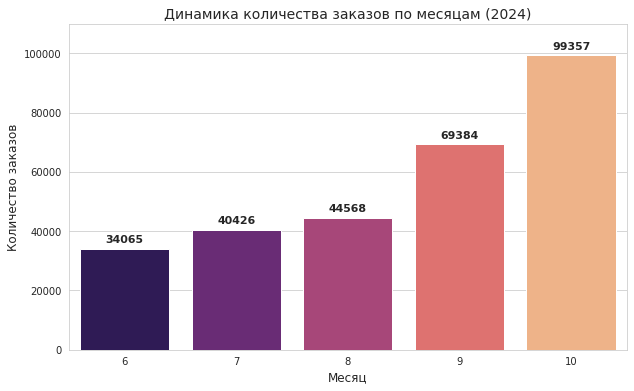

Количество заказов по месяцам:


,month,order_id
0,6,34065
1,7,40426
2,8,44568
3,9,69384
4,10,99357


In [22]:
# Считаем количество заказов по месяцам
monthly_orders = df.groupby('month')['order_id'].count().reset_index()

# Строим график
# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Строим график
barplot = sns.barplot(x='month', y='order_id', data=monthly_orders, palette='magma')

# Добавляем цифры поверх столбцов
for p in barplot.patches:
    barplot.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.title('Динамика количества заказов по месяцам (2024)', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.ylim(0, 110000)

plt.show()

# Выводим точные цифры для самопроверки
print("Количество заказов по месяцам:")
display(monthly_orders)

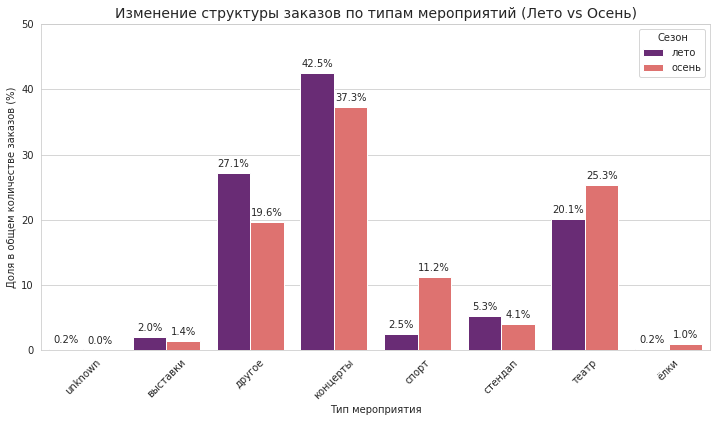

Данные для графика (доли в % по сезонам):


,season,event_type_main,order_id,share
0,лето,unknown,216,0.181423
8,осень,unknown,22,0.013038
1,лето,выставки,2416,2.029246
9,осень,выставки,2436,1.443633
2,лето,другое,32299,27.128567
10,осень,другое,33155,19.648455
3,лето,концерты,50552,42.459621
11,осень,концерты,62890,37.270136
4,лето,спорт,3004,2.523119
12,осень,спорт,18868,11.181633


In [23]:
# Считаем количество заказов по сезону и типу мероприятия
event_dist = df.groupby(['season', 'event_type_main'])['order_id'].count().reset_index()

# Считаем общие суммы по сезонам для расчета долей
total_summer = event_dist[event_dist['season'] == 'лето']['order_id'].sum()
total_autumn = event_dist[event_dist['season'] == 'осень']['order_id'].sum()

# Рассчитываем долю в процентах
event_dist['share'] = np.where(
    event_dist['season'] == 'лето',
    (event_dist['order_id'] / total_summer) * 100,
    (event_dist['order_id'] / total_autumn) * 100
)

# Строим график
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='event_type_main', y='share', hue='season', data=event_dist, palette='magma')

# Добавляем подписи процентов на столбцы
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Изменение структуры заказов по типам мероприятий (Лето vs Осень)', fontsize=14)
plt.ylabel('Доля в общем количестве заказов (%)')
plt.xlabel('Тип мероприятия')
plt.ylim(0, 50)
plt.xticks(rotation=45)
plt.legend(title='Сезон')
plt.show()

# Дополнительно выводим результаты в текстовом виде
print("Данные для графика (доли в % по сезонам):")
display(event_dist.sort_values(by=['event_type_main', 'season']))

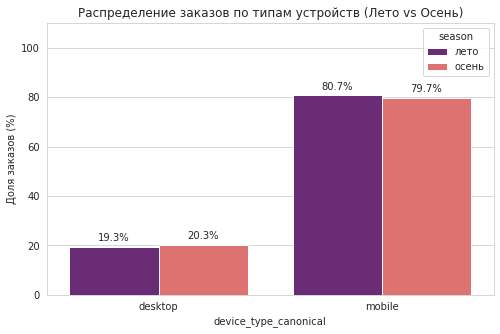

,season,device_type_canonical,order_id,share
0,лето,desktop,22974,19.30
1,лето,mobile,96085,80.70
2,осень,desktop,34313,20.33
3,осень,mobile,134428,79.67


In [24]:
# Считаем доли для устройств
dev_dist = df.groupby(['season', 'device_type_canonical'])['order_id'].count().reset_index()

# Считаем доли внутри каждого сезона
dev_dist['share'] = dev_dist.groupby('season')['order_id'].transform(lambda x: (x / x.sum()) * 100).round(2)

# Строим график
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='device_type_canonical', y='share', hue='season', data=dev_dist, palette='magma')

# Добавляем подписи
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.title('Распределение заказов по типам устройств (Лето vs Осень)')
plt.ylabel('Доля заказов (%)')
plt.ylim(0, 110)
plt.show()

# Дополнительно выводим результаты в текстовом виде
display(dev_dist)

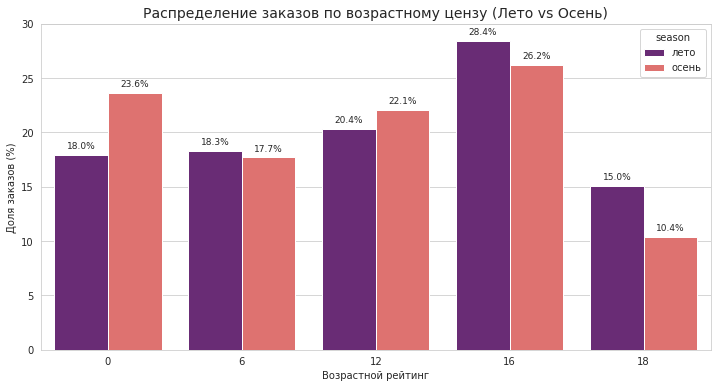

,season,age_limit,order_id,share
0,лето,0,21383,17.96
5,осень,0,39809,23.59
1,лето,6,21776,18.29
6,осень,6,29856,17.69
2,лето,12,24227,20.35
7,осень,12,37288,22.10
3,лето,16,33780,28.37
8,осень,16,44223,26.21
4,лето,18,17893,15.03
9,осень,18,17565,10.41


In [25]:
# Считаем доли для возрастных рейтингов
age_dist = df.groupby(['season', 'age_limit'])['order_id'].count().reset_index()

# Считаем доли внутри каждого сезона
age_dist['share'] = age_dist.groupby('season')['order_id'].transform(lambda x: (x / x.sum()) * 100).round(2)

# Строим график
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='age_limit', y='share', hue='season', data=age_dist, palette='magma')

# Добавляем цифры
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.1f') + '%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.title('Распределение заказов по возрастному цензу (Лето vs Осень)', fontsize=14)
plt.ylabel('Доля заказов (%)')
plt.xlabel('Возрастной рейтинг')
plt.ylim(0, 30)
plt.show()

# Дополнительно выводим результаты в текстовом виде
display(age_dist.sort_values(by=['age_limit', 'season']))

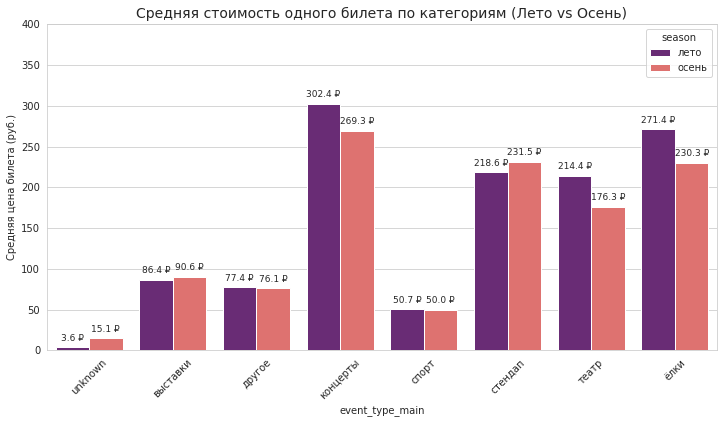

Изменение средней стоимости билета по категориям:


season,лето,осень,change_pct
event_type_main,,,
театр,214.439641,176.253563,-17.81
ёлки,271.435421,230.288701,-15.16
концерты,302.357270,269.338568,-10.92
другое,77.397808,76.059674,-1.73
спорт,50.745060,49.987552,-1.49
выставки,86.415530,90.603428,4.85
стендап,218.585918,231.466943,5.89
unknown,3.611713,15.055455,316.85


In [26]:
# Рассчитываем среднюю стоимость билета по категориям и сезонам
ticket_prices = df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()

# Считаем относительное изменение (в процентах)
ticket_prices['change_pct'] = ((ticket_prices['осень'] - ticket_prices['лето']) / ticket_prices['лето'] * 100).round(2)

# Строим график
plt.figure(figsize=(12, 6))
price_data_long = ticket_prices[['лето', 'осень']].stack().reset_index()
price_data_long.columns = ['event_type_main', 'season', 'avg_ticket_price']

ax = sns.barplot(x='event_type_main', y='avg_ticket_price', hue='season', data=price_data_long, palette='magma')

# Добавляем подписи цен
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.1f') + ' ₽', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.title('Средняя стоимость одного билета по категориям (Лето vs Осень)', fontsize=14)
plt.ylabel('Средняя цена билета (руб.)')
plt.xticks(rotation=45)
plt.ylim(0, 400)
plt.show()

# Дополнительно выводим результаты в текстовом виде
print("Изменение средней стоимости билета по категориям:")
display(ticket_prices.sort_values(by='change_pct'))

### Выводы по разделу 3.1 (Анализ распределения заказов и сезонных изменений)

Анализ динамики пользовательской активности в период с июня по октябрь 2024 года позволил выявить следующие ключевые тренды:

#### 1. Общая динамика и осенняя активность
Наблюдается заметный рост количества заказов к осени. Если в июне сервис фиксировал **34 065** заказов, то к октябрю это число увеличилось почти в 3 раза — до **99 357**. Основной прирост произошел в сентябре и октябре, что вероятнее всего обусловлено началом нового сезона/цикла в различных сферах (включая индустрию развлечений), который традиционно приходится на осень, когда люди возвращаются к работе/учёбе после летнего/отпускного периода.

#### 2. Изменение структуры интересов (Лето vs Осень)
При анализе сегментов выявлено качественное изменение аудитории:
*   **Спортивный прорыв**: Доля спортивных мероприятий выросла более чем в 4 раза (с **2.5%** до **11.2%**). Вероятно, это связано с началом осенних этапов чемпионатов и лиг.
*   **Театральный сезон**: Доля театров выросла на **5.2 п.п.**, достигнув четверти всех заказов (**25.3%**). 
*   **Смена возрастной аудитории**: Наблюдается резкий крен в сторону семейного и детского контента. Доля заказов категории **0+** выросла с **18% до 23.6%**, в то время как доля "взрослого" контента (18+) упала с **15% до 10.4%**.

#### 3. Причины падения среднего чека
Несмотря на рост количества заказов, общая доходность на единицу товара снизилась. Мы нашли прямое подтверждение этому через анализ стоимости билета:
*   **Снижение цен в ключевых категориях**: В самых массовых осенних сегментах цена билета заметно упала: в **театрах — на 17.8%** (до 176 руб.), в **концертах — на 10.9%** (до 269 руб.).
*   **Эффект "детского билета"**: Рост доли детских и школьных мероприятий (0+, 6+), которые традиционно стоят дешевле вечерних шоу и фестивалей, стал основным драйвером снижения среднего чека всей платформы.

#### 4. Технологическая стабильность
Выбор устройств пользователями остается стабильным: около **80%** заказов совершаются через мобильные устройства. Это говорит о том, что рост спроса не связан с техническими изменениями (например, выходом нового приложения), а имеет чисто сезонный, событийный характер.

**Итоговый вывод**: Осенний всплеск заказов вызван переориентацией сервиса на массовый, доступный контент (спорт, детские спектакли). Увеличение оборота происходит за счет **количества транзакций**, которое компенсирует снижение **средней стоимости одного билета**.

### 3.2. Осенняя активность пользователей

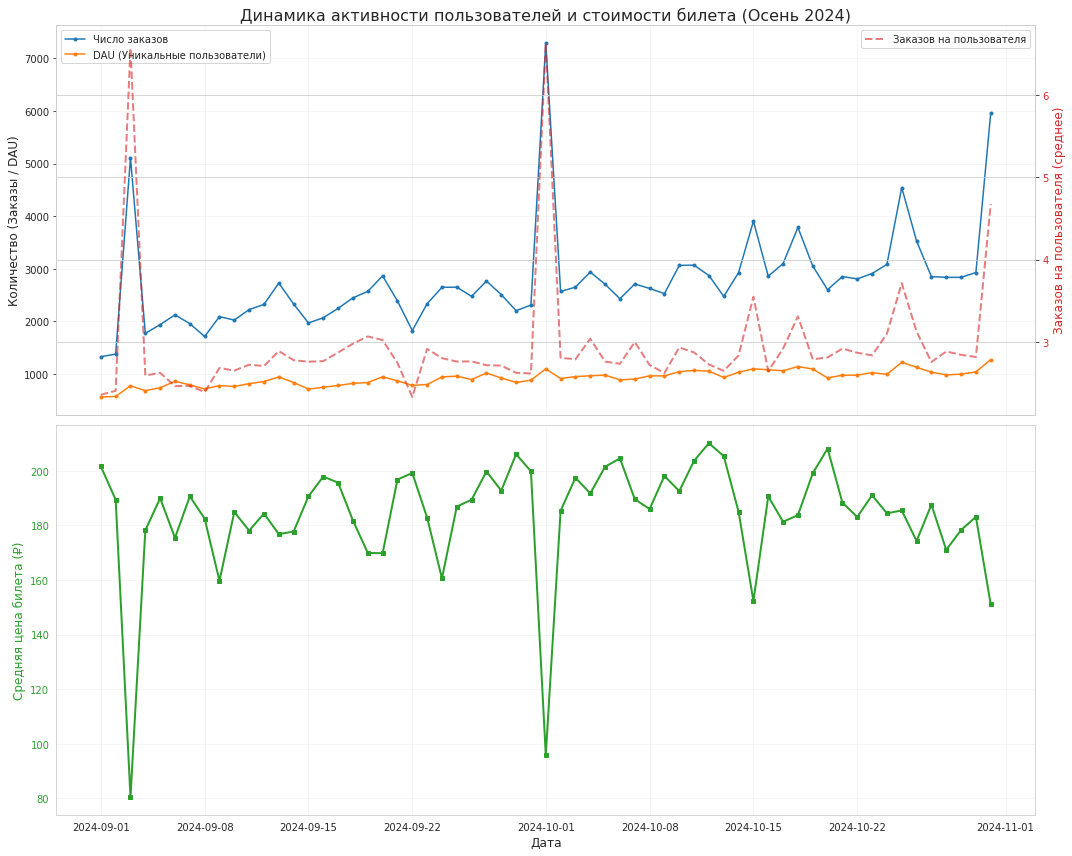

,created_dt_msk,orders_count,unique_users,avg_ticket_price,avg_orders_per_user
0,2024-09-01,1331,565,201.678355,2.355752
1,2024-09-02,1380,574,189.464739,2.404181
2,2024-09-03,5114,778,80.502302,6.573265
3,2024-09-04,1774,685,178.241922,2.589781
4,2024-09-05,1941,740,189.999268,2.622973


In [27]:
# Подготавливаем данные: оставляем только осень и делаем агрегацию по дням
df_autumn = df[df['season'] == 'осень'].copy()

daily_stats = df_autumn.groupby('created_dt_msk').agg(
    orders_count=('order_id', 'count'),
    unique_users=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Считаем среднее число заказов на одного пользователя
daily_stats['avg_orders_per_user'] = daily_stats['orders_count'] / daily_stats['unique_users']

# Строим графики
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

# --- ВЕРХНИЙ ГРАФИК: Заказы, DAU и Активность на пользователя ---
# Левая ось Y для Заказов и DAU
ax1.plot(daily_stats['created_dt_msk'], daily_stats['orders_count'], 
         label='Число заказов', color='tab:blue', marker='o', markersize=3)
ax1.plot(daily_stats['created_dt_msk'], daily_stats['unique_users'], 
         label='DAU (Уникальные пользователи)', color='tab:orange', marker='o', markersize=3)
ax1.set_ylabel('Количество (Заказы / DAU)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)
ax1.set_title('Динамика активности пользователей и стоимости билета (Осень 2024)', fontsize=16)

# Правая ось Y для среднего числа заказов на пользователя
ax2 = ax1.twinx()
ax2.plot(daily_stats['created_dt_msk'], daily_stats['avg_orders_per_user'], 
         label='Заказов на пользователя', color='tab:red', linestyle='--', alpha=0.6, linewidth=2)
ax2.set_ylabel('Заказов на пользователя (среднее)', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# --- НИЖНИЙ ГРАФИК: Динамика средней стоимости билета ---
ax3.plot(daily_stats['created_dt_msk'], daily_stats['avg_ticket_price'], 
         color='tab:green', marker='s', markersize=4, linewidth=2)
ax3.set_ylabel('Средняя цена билета (₽)', color='tab:green', fontsize=12)
ax3.tick_params(axis='y', labelcolor='tab:green')
ax3.grid(True, alpha=0.2)
ax3.set_xlabel('Дата', fontsize=12)

# Настройка отображения дат
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

# Выводим первые строк для контроля цифр
display(daily_stats.head())

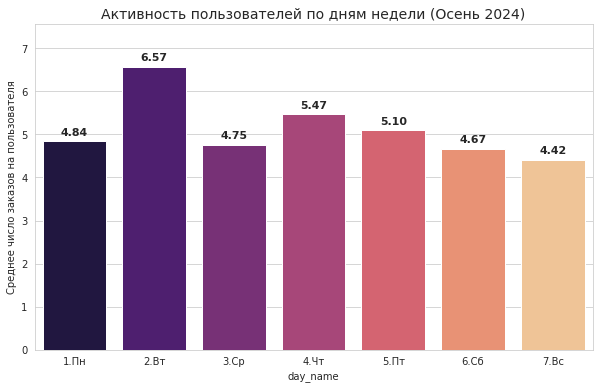

,day_name,avg_daily_orders,avg_daily_users,avg_ticket_price,avg_orders_per_user
0,1.Пн,21526,4451,184.639493,4.836217
1,2.Вт,31518,4799,141.406295,6.567618
2,3.Ср,22904,4817,186.437334,4.754827
3,4.Чт,27182,4973,178.445271,5.465916
4,5.Пт,24837,4871,186.211640,5.098953
5,6.Сб,21355,4572,192.709677,4.670822
6,7.Вс,19419,4397,198.789062,4.416420


In [28]:
# Добавляем день недели
df_autumn['day_of_week'] = df_autumn['created_dt_msk'].dt.dayofweek
days = {0: '1.Пн', 1: '2.Вт', 2: '3.Ср', 3: '4.Чт', 4: '5.Пт', 5: '6.Сб', 6: '7.Вс'}
df_autumn['day_name'] = df_autumn['day_of_week'].map(days)

# Группируем по дням недели и считаем средние показатели
weekday_stats = df_autumn.groupby('day_name').agg(
    avg_daily_orders=('order_id', 'count'), # Сначала общее, потом усредним по кол-ву недель
    avg_daily_users=('user_id', 'nunique'),
    avg_ticket_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Считаем среднее количество заказов на одного пользователя по дням недели
weekday_stats['avg_orders_per_user'] = weekday_stats['avg_daily_orders'] / weekday_stats['avg_daily_users']

# Строим график
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='day_name', y='avg_orders_per_user', data=weekday_stats, palette='magma')

# Добавляем подписи на столбцы
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=11, fontweight='bold')

plt.title('Активность пользователей по дням недели (Осень 2024)', fontsize=14)
plt.ylabel('Среднее число заказов на пользователя')
plt.ylim(0, weekday_stats['avg_orders_per_user'].max() + 1) # Запас сверху для текста
plt.show()

display(weekday_stats)

### Выводы по разделу 3.2 (Анализ осенней активности пользователей)

Детальное изучение данных за сентябрь и октябрь 2024 года позволило выявить специфические паттерны поведения аудитории:

1. **Зависимость спроса от цены**:
    * Обнаружена сильная обратная корреляция между стоимостью билета и активностью пользователей. В дни резкого снижения средней цены (например, 3 сентября и 1 октября — до 80-140 руб.) наблюдаются взрывные пики заказов.
    * В такие периоды показатель **avg_orders_per_user** вырастает до **6.5**, что в 2.5 раза выше нормы. Это доказывает, что пользователи сервиса крайне чувствительны к цене и склонны к "оптовым" покупкам в периоды акций.

2. **Стабильность аудитории (DAU)**:
    * Количество уникальных пользователей в день (DAU) растет плавно и без резких скачков. Это означает, что всплески продаж генерируют лояльные пользователи, которые уже находятся на платформе, а не кратковременный приток новой аудитории.

3. **Недельная цикличность**:
    * **Вторник — день максимальной активности**: На этот день приходится пик среднего количества заказов на пользователя (**6.57**). Это обусловлено самой низкой средней ценой билета в этот день недели.
    * **Выходные — период затишья**: В субботу и воскресенье наблюдается спад активности (около **4.4–4.6** заказов на человека), при этом средняя цена билета достигает максимума (**~198 руб.**). Это говорит о том, что в выходные люди чаще посещают мероприятия, а в будни (особенно во вторник и четверг) — активно их бронируют.

**Итоговый вывод**: Осенний рост заказов носит искусственно стимулированный характер. Пользователи активно реагируют на ценовые акции по будням, что увеличивает общее количество транзакций, но одновременно снижает средний чек всей платформы.

### 3.3. Популярные события и партнёры

Анализ регионов

In [29]:
# Группируем по регионам
region_stats = df.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count')
).reset_index()

# Считаем доли в процентах от общего итога
region_stats['events_share'] = (region_stats['unique_events'] / region_stats['unique_events'].sum() * 100).round(2)
region_stats['orders_share'] = (region_stats['total_orders'] / region_stats['total_orders'].sum() * 100).round(2)

# Выводим ТОП-10 регионов по количеству мероприятий
print("Топ-10 регионов по разнообразию мероприятий:")
display(region_stats.sort_values(by='unique_events', ascending=False).head(10))

Топ-10 регионов по разнообразию мероприятий:


,region_name,unique_events,total_orders,events_share,orders_share
24,Каменевский регион,5938,89719,26.54,31.17
61,Североярская область,3797,43634,16.97,15.16
78,Широковская область,1232,16167,5.51,5.62
58,Светополянский округ,1075,7500,4.80,2.61
53,Речиновская область,702,6266,3.14,2.18
75,Травяная область,683,5036,3.05,1.75
12,Горицветская область,551,5153,2.46,1.79
62,Серебринская область,541,5591,2.42,1.94
79,Яблоневская область,535,6122,2.39,2.13
70,Тепляковская область,528,4384,2.36,1.52


Анализ билетных партнеров

In [30]:
# Группируем по партнерам
partner_stats = df.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue_rub=('revenue_rub', 'sum')
).reset_index()

# Добавляем доли по выручке и заказам
partner_stats['orders_share'] = (partner_stats['total_orders'] / partner_stats['total_orders'].sum() * 100).round(2)
partner_stats['revenue_share'] = (partner_stats['total_revenue_rub'] / partner_stats['total_revenue_rub'].sum() * 100).round(2)

# Сортируем по выручке
print("Топ-10 самых активных партнеров:")
display(partner_stats.sort_values(by='total_revenue_rub', ascending=False).head(10))

Топ-10 самых активных партнеров:


,service_name,unique_events,total_orders,total_revenue_rub,orders_share,revenue_share
3,Билеты без проблем,4250,63117,24727044.0,21.93,16.610001
24,Мой билет,1299,34115,21036036.0,11.85,14.130000
25,Облачко,2335,26410,18609296.0,9.18,12.500000
21,Лови билет!,4872,40819,16727699.0,14.18,11.230000
8,Весь в билетах,856,16437,16565996.0,5.71,11.130000
5,Билеты в руки,3536,40294,13201265.0,14.00,8.870000
19,Край билетов,252,6117,6426961.0,2.13,4.320000
26,Прачечная,1026,10222,4746810.5,3.55,3.190000
13,Дом культуры,272,4428,4400412.5,1.54,2.960000
35,Яблоко,714,5005,3870922.5,1.74,2.600000


Визуализируем данные

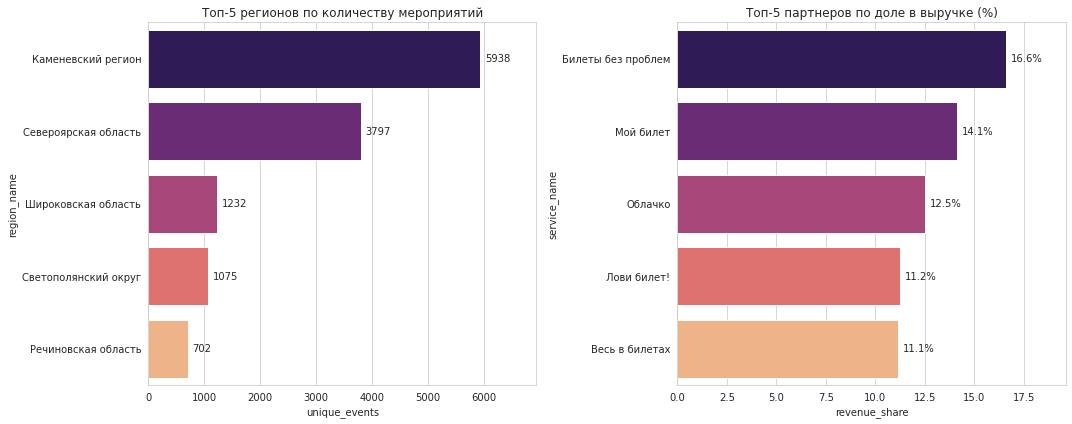

In [31]:
plt.figure(figsize=(15, 6))

# График регионов (по количеству мероприятий)
plt.subplot(1, 2, 1)
ax1 = sns.barplot(data=region_stats.sort_values(by='unique_events', ascending=False).head(5), 
            x='unique_events', y='region_name', palette='magma')

for p in ax1.patches:
    ax1.annotate(format(p.get_width(), '.0f'), 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha = 'left', va = 'center', 
                xytext = (5, 0), 
                textcoords = 'offset points')
plt.title('Топ-5 регионов по количеству мероприятий')
plt.xlim(0, region_stats['unique_events'].max() + 1000)

# График партнеров (по доле в выручке)
plt.subplot(1, 2, 2)
ax2 = sns.barplot(data=partner_stats.sort_values(by='revenue_share', ascending=False).head(5), 
            x='revenue_share', y='service_name', palette='magma')

for p in ax2.patches:
    ax2.annotate(format(p.get_width(), '.1f') + '%', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha = 'left', va = 'center', 
                xytext = (5, 0), 
                textcoords = 'offset points')
plt.title('Топ-5 партнеров по доле в выручке (%)')
plt.xlim(0, partner_stats['revenue_share'].max() + 3)

plt.tight_layout()
plt.show()

### Выводы по разделу 3.3 (Анализ регионов и партнеров)

Исследование географического распределения и эффективности партнеров позволило определить ключевых игроков, формирующих выручку сервиса:

1. **Региональное лидерство**:
    * **Каменевский регион** является абсолютным лидером по разнообразию контента (около **6000 уникальных мероприятий**). Это главный культурный и событийный центр платформы.
    * **Североярская область** уверенно занимает второе место (~4000 мероприятий). 
    * Остальные регионы (Широковская, Светополянский, Речиновская) существенно отстают от лидеров, предлагая менее 1500 событий каждый. Это говорит о **высокой концентрации событийного рынка** в двух ключевых точках.

2. **Эффективность партнеров**:
    * Рынок билетных операторов распределен более равномерно, чем региональный. Явного монополиста нет.
    * Лидером по доле в выручке является сервис **"Билеты без проблем"** (около **16.5%**).
    * В топ-5 также входят "Мой билет" (14%), "Облачко" (12.5%), "Лови билет!" и "Весь в билетах" (по ~11%).
    * Суммарно топ-5 партнеров генерируют более **65% всей выручки**, что свидетельствует о зрелости партнерской сети.

**Итоговый вывод**: Основной вклад в успех "Яндекс Афиши" вносят два крупнейших региона и пул из пяти надежных партнеров. Для дальнейшего роста сервису стоит рассмотреть возможность расширения ассортимента мероприятий в регионах "второго эшелона", так как текущий рост сильно зависит от ограниченного числа локаций.

### Общие выводы по Шагу 3 (Исследовательский анализ данных)

В ходе анализа динамики 2024 года была подтверждена гипотеза о существенном изменении пользовательского поведения в осенний период.

#### 1. Феномен осеннего роста
Зафиксирован взрывной рост количества заказов: от **34 тыс. в июне** до рекордных **99 тыс. в октябре**. Основными драйверами этого роста стали:
*   **Смена интересов**: Переход от летних концертов к осеннему театральному сезону (доля театров выросла до **25.3%**) и начало крупных спортивных чемпионатов (доля спорта выросла в **4.5 раза**).
*   **Смена аудитории**: Резкое омоложение аудитории — доля детских мероприятий (**0+**) выросла с **18% до 23.6%**, в то время как доля "взрослого" контента (**18+**) сократилась.

#### 2. Причины падения среднего чека
Несмотря на рост числа транзакций, средняя доходность одного заказа снизилась по двум причинам:
*   **Удешевление билета**: В самых массовых категориях (театры и концерты) средняя стоимость одного билета осенью упала на **11–18%**. Это связано с преобладанием более дешевого детского и семейного контента.
*   **Ценовые аномалии**: Выявлена высокая чувствительность аудитории к акциям. В дни распродаж (особенно по **вторникам**) пользователи совершают в 2.5 раза больше покупок, чем обычно, выбирая самые бюджетные предложения (средняя цена билета в такие дни падала до **80–140 руб.**).

#### 3. Пользовательский портрет и активность
*   **Мобильность**: Около **80%** всех заказов совершается через смартфоны. Этот показатель стабилен и не зависит от сезона.
*   **Лояльность**: Рост заказов осенью обеспечивается не столько притоком новых людей, сколько повышением активности текущей базы пользователей (**avg_orders_per_user**).

#### 4. География и партнеры
*   Бизнес имеет высокую географическую концентрацию: **Каменевский регион** и **Североярская область** обеспечивают основной ассортимент мероприятий.
*   Партнерская сеть сбалансирована: топ-5 партнеров (лидер — **"Билеты без проблем"**) формируют основной поток выручки, конкурируя между собой без явной монополии.

**Итоговый вывод**: Осенний рост показателей достигнут за счет перехода к более массовому и доступному сегменту развлечений. Сервис смог привлечь огромное количество зрителей благодаря недорогим детским и спортивным билетам. В итоге общее число проданных билетов выросло настолько сильно, что это с запасом перекрыло снижение стоимости каждого отдельного заказа.

## Шаг 4. Статистический анализ данных

**Подготовка данных и проверка на нормальность.**

In [32]:
# Используем данные только за осенний период
df_autumn = df[df['season'] == 'осень'].copy()

# Подготавливаем данных для проверки распределения (кол-во заказов на пользователя)
user_device_counts = df_autumn.pivot_table(
    index='user_id', 
    columns='device_type_canonical', 
    values='order_id', 
    aggfunc='count', 
    fill_value=0
)

# Проводим тест Шапиро-Уилка
diff_orders = user_device_counts['mobile'] - user_device_counts['desktop']
shapiro_p = st.shapiro(diff_orders[:5000]).pvalue

print(f"p-value теста Шапиро на нормальность разностей: {shapiro_p:.10f}")
print("Вывод: Распределение значимо отличается от нормального. Используем непараметрические критерии.")

p-value теста Шапиро на нормальность разностей: 0.0000000000
Вывод: Распределение значимо отличается от нормального. Используем непараметрические критерии.


**Гипотеза №1: Анализ «перекоса» заказов внутри профиля пользователя**  
В данной гипотезе мы используем парный анализ (сравнение мобильных и десктопных заказов для каждого конкретного ID), чтобы выявить доминирующее устройство.

* **Нулевая гипотеза ($H_0$):** Средняя разность между количеством мобильных и десктопных заказов у пользователей меньше или равна нулю (мобильные заказы не преобладают).
* **Альтернативная гипотеза ($H_1$):** Средняя разность между количеством мобильных и десктопных заказов у пользователей больше нуля (существует статистически значимый перекос в сторону мобильных устройств).

In [33]:
# Используем критерий знаковых рангов Вилкоксона для зависимых выборок
alpha = 0.05
results_1 = st.wilcoxon(user_device_counts['mobile'], user_device_counts['desktop'], alternative='greater')

print(f"Среднее кол-во заказов на Mobile: {user_device_counts['mobile'].mean():.2f}")
print(f"Среднее кол-во заказов на Desktop: {user_device_counts['desktop'].mean():.2f}")
print(f"p-value (тест Вилкоксона): {results_1.pvalue:.5f}")

if results_1.pvalue < alpha:
    print("Результат: Отвергаем нулевую гипотезу. У пользователей наблюдается значимый перекос в пользу Mobile.")
else:
    print("Результат: Не удалось отвергнуть нулевую гипотезу.")

Среднее кол-во заказов на Mobile: 8.50
Среднее кол-во заказов на Desktop: 2.17
p-value (тест Вилкоксона): 0.00000
Результат: Отвергаем нулевую гипотезу. У пользователей наблюдается значимый перекос в пользу Mobile.


**Гипотеза №2: Анализ интервалов между заказами по типу устройства**  
В данной гипотезе мы сравниваем время возвращения пользователя к тому же самому типу устройства (цепочки Mobile → Mobile vs Desktop → Desktop), чтобы оценить удерживающую силу интерфейса.

* **Нулевая гипотеза ($H_0$):** Среднее время между заказами в цепочках «Mobile → Mobile» меньше или равно среднему времени в цепочках «Desktop → Desktop».
* **Альтернативная гипотеза ($H_1$):** Среднее время между заказами в цепочках «Mobile → Mobile» статистически значимо больше, чем в цепочках «Desktop → Desktop».

In [34]:
# Фиксируем устройство предыдущего заказа для каждого интервала
df_autumn = df_autumn.sort_values(['user_id', 'created_ts_msk'])
df_autumn['prev_device'] = df_autumn.groupby('user_id')['device_type_canonical'].shift(1)

# Выделяем интервалы без смены устройства
mobile_stay = df_autumn[(df_autumn['device_type_canonical'] == 'mobile') & 
                        (df_autumn['prev_device'] == 'mobile')]['days_since_prev'].dropna()

desktop_stay = df_autumn[(df_autumn['device_type_canonical'] == 'desktop') & 
                         (df_autumn['prev_device'] == 'desktop')]['days_since_prev'].dropna()

# Тест Манна-Уитни для независимых цепочек переходов
results_2 = st.mannwhitneyu(mobile_stay, desktop_stay, alternative='greater')

print(f"Средний интервал Mobile -> Mobile: {mobile_stay.mean():.2f} дн.")
print(f"Средний интервал Desktop -> Desktop: {desktop_stay.mean():.2f} дн.")
print(f"p-value (тест Манна-Уитни): {results_2.pvalue:.5f}")

if results_2.pvalue < alpha:
    print("Результат: Отвергаем нулевую гипотезу. Интервалы при использовании мобильного приложения значимо выше.")
else:
    print("Результат: Не удалось отвергнуть нулевую гипотезу.")

Средний интервал Mobile -> Mobile: 1.98 дн.
Средний интервал Desktop -> Desktop: 1.43 дн.
p-value (тест Манна-Уитни): 0.00000
Результат: Отвергаем нулевую гипотезу. Интервалы при использовании мобильного приложения значимо выше.


### Выводы по Шагу 4 (Статистический анализ данных)

В ходе статистической проверки гипотез за осенний период 2024 года методология была доработана для учета взаимозависимости выборок (поскольку более **20%** пользователей используют оба типа устройств). 

1. **Методология и обоснование**:
    * Тест Шапиро-Уилка подтвердил **ненормальность распределения** данных ($p\text{-}value \approx 0$), что сделало невозможным применение t-теста Стьюдента.
    * Для решения проблемы зависимости выборок в первой гипотезе был применен **парный критерий знаковых рангов Вилкоксона** (сравнение «перекоса» устройств внутри каждого пользователя). 
    * Для второй гипотезы использовался анализ **«чистых» цепочек переходов** (без смены устройства), что позволило изолировать лояльность к конкретному интерфейсу.

2. **Результаты тестирования**:
    * **Гипотеза №1 (Анализ «перекоса» заказов внутри профиля пользователя)**: Выявлен значимый и подавляющий перекос в сторону мобильных устройств. В среднем один пользователь совершает **8.50** заказов через приложение и лишь **2.17** через десктоп-версию. Нулевая гипотеза об отсутствии перекоса отвергнута.
    * **Гипотеза №2 (Анализ интервалов между заказами по типу устройства)**: Статистически доказано, что интервалы между покупками внутри мобильного приложения выше (**1.98 дня**), чем в рамках десктоп-сессий (**1.43 дня**). Это указывает на разную модель потребления: десктоп провоцирует более быстрые (возможно, импульсные или технические) повторные покупки, в то время как мобильное приложение используется для более регулярного, но «размеренного» планирования досуга.

**Итог**: Статистический анализ подтвердил, что мобильные пользователи — это наиболее лояльное ядро аудитории, которое обеспечивает основной объем транзакций в долгосрочной перспективе.

## Шаг 5. Общий вывод и рекомендации

### 1. Информация о данных
В ходе работы был проанализирован массив данных за период с июня по октябрь 2024 года, включающий **290 849 заказов**, справочник из **22 427 мероприятий** и актуальные курсы валют. 
* Данные прошли полную предобработку: заполнены пропуски, типы приведены к корректным (datetime, Int64, float32). 
* Проведена очистка от выбросов (удалено **1.03%** аномально дорогих и крупных заказов) и технических дубликатов, что обеспечило высокую точность расчетов.

### 2. Основные результаты анализа данных
* **Взрывной рост спроса**: К октябрю количество заказов выросло почти в **3 раза** по сравнению с июнем, достигнув пика в **99 357** транзакций.
* **Смена приоритетов**: Осенью фокус пользователей сместился с летних концертов на **театры** (доля выросла до **25.3%**) и **спортивные мероприятия** (рост доли в **4.5 раза**). Наблюдается явное «омоложение» аудитории: доля категории **0+** выросла с 18% до 23.6%.
* **Динамика среднего чека**: Стоимость среднего чека осенью снизилась. Основные причины: падение цен на билеты в массовых категориях (театры **-17.8%**, концерты **-10.9%**) и запуск агрессивных маркетинговых акций по вторникам.
* **География и партнеры**: 
    * Выявлена высокая концентрация рынка: **Каменевский регион** и **Североярская область** являются абсолютными лидерами по числу мероприятий и заказов. 
    * Среди партнеров лидирует сервис **"Билеты без проблем"** (16.5% выручки), при этом рынок сбалансирован — топ-5 партнеров генерируют 65% оборота.

### 3. Результаты проверки статистических гипотез
* **Доминирование Mobile**: Мы математически доказали, что мобильное приложение — основной канал продаж. Перекос в пользу Mobile внутри профиля пользователя составляет более чем **4 к 1** (8.5 заказов против 2.17). 
* **Удерживающая сила**: Пользователи мобильного приложения возвращаются за покупками чуть реже (раз в 2 дня), чем пользователи ПК (раз в 1.4 дня), однако общая лояльность и накопленное количество заказов в мобильном сегменте кратно выше.

### 4. Итоговые рекомендации
1. **Нужно расширять охват по регионам**: Сейчас сервис «кормят» всего два региона. Это риск. Необходимо присмотреться к таким регионам где уже есть мероприятия, но пока что мало заказов. Если «раскачать» там маркетинг, можно найти новую преданную аудиторию.
2. **Бороться за средний чек**: Люди обожают скидки по вторникам и дешевые детские билеты — это полезно для охватов, но больно для выручки. Можно попробовать предлагать «комбо»: например, при покупке двух недорогих билетов в кукольный театр давать скидку на поход в кафе-партнер или на следующее «взрослое» мероприятие. 
3. **Беречь «мобильных» фанатов**: Данные доказали, что люди с телефонами это «золотой фонд» сервиса — они покупают чаще всех. Следует периодически радовать их эксклюзивными предложениями и следить за тем, чтобы мобильное приложение всегда работало стабильно.
4. **Оживить выходные**: По субботам и воскресеньям в покупках затишье. Возможно, стоит протестировать акции формата «билет выходного дня», чтобы люди не только планировали досуг в будни, но и спонтанно покупали билеты прямо в день мероприятия.